## Manually placed arbitrary colorbars

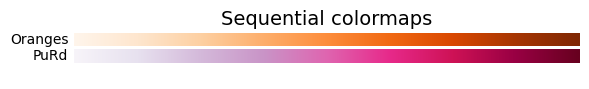

In [6]:
import joblib
from config import *

def plot_color_gradients(category, cmap_list):
    # Create figure and adjust figure height to number of colormaps
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import numpy as np
    cmaps = {}

    gradient = np.linspace(0, 1, 256)
    gradient = np.vstack((gradient, gradient))

    nrows = len(cmap_list)
    figh = 0.35 + 0.15 + (nrows + (nrows - 1) * 0.1) * 0.22
    fig, axs = plt.subplots(nrows=nrows + 1, figsize=(6.4, figh))
    fig.subplots_adjust(top=1 - 0.35 / figh, bottom=0.15 / figh,
                        left=0.2, right=0.99)
    axs[0].set_title(f'{category} colormaps', fontsize=14)

    for ax, name in zip(axs, cmap_list):
        ax.imshow(gradient, aspect='auto', cmap=mpl.colormaps[name])
        ax.text(-0.01, 0.5, name, va='center', ha='right', fontsize=10,
                transform=ax.transAxes)

    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs:
        ax.set_axis_off()
    
    plt.savefig(projdir + '/figs/ohbm26/figs_colorbars.svg')

plot_color_gradients('Sequential',
                     ['Oranges', 'PuRd'])


## fig 1 a

In [7]:
mesh = joblib.load(projdir + '/data/fsLR-4k_reduced-midthickness_neuromaps.pkl')
sphere = joblib.load(projdir + '/data/fsLR-4k_sphere_grf.pkl')

In [8]:
sphere.array_names

['field', '25', '50', '75', '100']

In [9]:
test_ranges

[25, 50, 75, 100]

In [10]:
mesh_aes = {"show_scalar_bar": False,\
            "smooth_shading": True,\
            "specular": 0, "diffuse":0, "ambient":1}

points_aes = {"show_scalar_bar": False,\
            "render_points_as_spheres": True,\
            "point_size": 12,\
            "specular": 0, "diffuse":0, "ambient":1}

Maximum number of clients reached
2025-12-01 14:55:55.003 (   8.243s) [    7F8297F6DB80]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=:1
Maximum number of clients reached


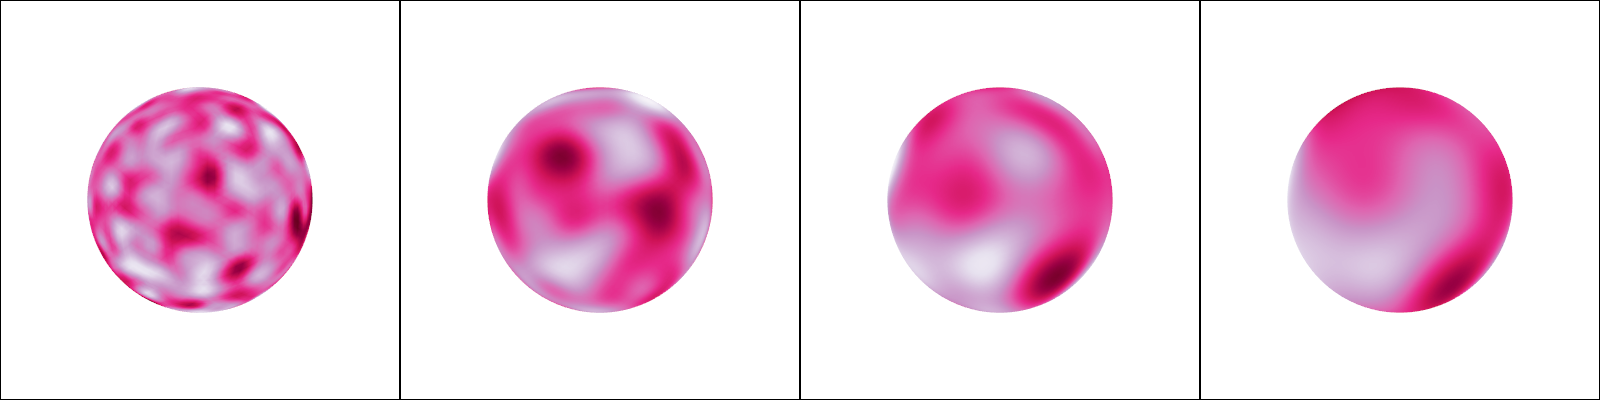

In [11]:
import copy
import pyvista as pv


pl0 = pv.Plotter(shape = (1, len(test_ranges)), window_size = (1600, 400))

for ti, test_range in enumerate(test_ranges):
    pl0.subplot(0,ti)
    tmp = copy.copy(sphere)
    pl0.add_mesh(tmp, scalars = str(test_range), cmap = 'PuRd', **mesh_aes)
    pl0.camera_position = 'xy'

pl0.save_graphic(projdir + '/figs/ohbm26/fig1_grf_spheres.svg')
pl0.show(jupyter_backend = 'static')

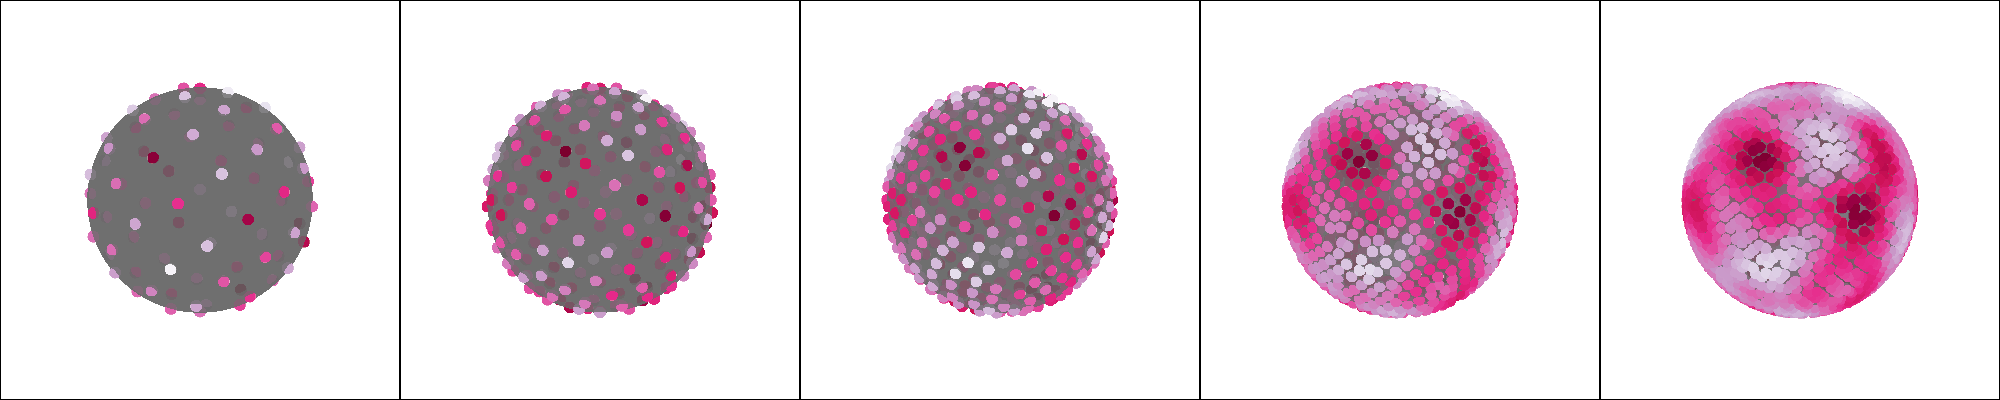

In [12]:
pl0 = pv.Plotter(shape = (1,5), window_size = (2000, 400))

for pi, test_percentage in enumerate(test_percentages):

    sphere_sampling = joblib.load(projdir + f'/data/sampling/fsLR-4k_sphere_samp-fibonacci_pct-{str(test_percentage)}.pkl')
    known_coords = sphere_sampling[1][0][:,:,0]
    known_verts = sphere_sampling[1][1][:,0].astype(int)

    pl0.subplot(0,pi)
    pl0.add_mesh(sphere, color = 'dimgrey',opacity = .8, **mesh_aes)
    pl0.add_points(known_coords, scalars = sphere[str(test_ranges[1])][known_verts], cmap = 'PuRd', **points_aes)
    
    pl0.camera_position = 'xy'

#pl0.save_graphic(projdir + '/figs/ohbm26/fig1_grf_sphere_sampling.svg')
pl0.show(jupyter_backend = 'static')

## fig 1 b

In [253]:
import matplotlib.pyplot as plt
import pandas as pd

datasource='grf'
strategy='fibonacci'
geometry='sphere'


data = pd.DataFrame([None])
for maptag in test_ranges:    

    for percentage in test_percentages:

        res = joblib.load(outdir + f'/{datasource}/{strategy}/{template}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')

        scores = res['performance'][1]
        pearson = res['performance'][0].iloc[0]
        spearman = res['performance'][0].iloc[1]
        ssim = res['performance'][0].iloc[2]
        r2 = res['performance'][0].iloc[3]
        rmse = res['performance'][0].iloc[4]
        ks = res['performance'][0].iloc[5]
        js = res['performance'][0].iloc[6]
        run_time = res['performance'][0].iloc[7]

        percentage_col = pd.DataFrame( [percentage] * len(scores), index=scores.index)
        maptag_col = pd.DataFrame( [maptag] * len(scores), index=scores.index)

        tmp_data = pd.concat( [ scores, pearson, spearman, ssim, r2, rmse, ks, js, run_time, percentage_col, maptag_col ], axis = 1)
        tmp_data.columns = ['score'] + metrics_to_consider + ['percentage', 'maptag']

        if data.empty: data = tmp_data
        else: data = pd.concat( [data, tmp_data] )


data = data.drop(0, axis = 0)
data = data.drop(0, axis = 1)

data['approach'] = data.index
data.index = range(len(data))


In [254]:
import numpy as np
data['category'] = np.empty(len(data))
for rowid in range(len(data)):
    if data.at[rowid, 'approach'] in ['krige', 'regkrige', 'swr']: data.at[rowid, 'category'] = 'spatial'
    if data.at[rowid, 'approach'] in ['idw', 'knn', 'rbf']: data.at[rowid, 'category'] = 'deterministic'
        

In [255]:
datasource = 'grf'
strategy = 'fibonacci'
template = 'fsLR-4k'
geometry = 'sphere'

import sys
sys.path.append('../')
from interpmodules import helpers, metrics

rmse_vario = np.zeros((len(test_ranges), len(test_percentages)))

for rowid in range(len(data)):

    if np.isnan(data.at[rowid, "score"]): continue
    if data.at[rowid, "approach"] == "krige" or data.at[rowid, "approach"] == "regkrige":
        
        maptag = data.at[rowid, "maptag"].astype(int)
        percentage = data.at[rowid, "percentage"].astype(int)
    
        res = joblib.load(outdir + f'/{datasource}/{strategy}/{template}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')
        x,y,N,eff_range,psill,nugg = res['variogram']
    
        theoretical = [ helpers.gaussian(h=xi, r=eff_range, c0=psill, nugget=nugg) for xi in x ] 
        if np.isnan(y).any(): y[ np.where( np.isnan(y) )[0] ] = 0
        data.at[rowid,"rmse_vario"] = metrics.metric(theoretical, y, 'rmse')

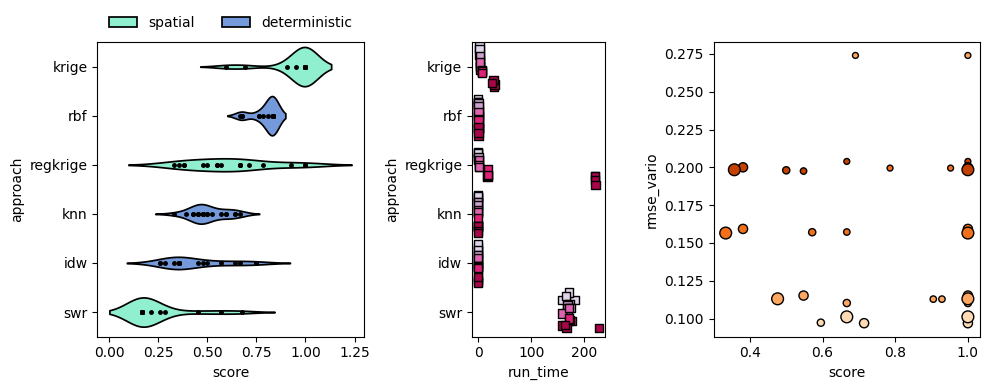

In [256]:
import seaborn as sns

colors = ["aquamarine", "cornflowerblue"]
grf_pal = {"percentage": sns.color_palette('PuRd', n_colors = len(test_percentages)), \
           "maptag": sns.color_palette('Oranges', n_colors = len(test_ranges))}

scatter_aes = {"linewidth":1, "edgecolor":'k', "legend":False}

fig, axs = plt.subplots(1,3,figsize = (10,4), gridspec_kw={'width_ratios':[2,1,2]})
sns.violinplot(data, x='score', y ='approach', hue = 'category', \
               order=data.groupby('approach')['score'].mean().sort_values(ascending=False).index, \
               inner = 'points', palette = sns.color_palette(colors), linecolor = 'k', ax=axs[0])
sns.move_legend(
    axs[0], "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
sns.stripplot(data, x="run_time", y="approach", hue="percentage", dodge = 1 ,jitter = 0.5,\
              order=data.groupby('approach')['score'].mean().sort_values(ascending=False).index, \
              palette = grf_pal['percentage'], marker = 's', size = 6, **scatter_aes, ax = axs[1])

sns.scatterplot(data, x = "score", y = "rmse_vario", hue = "maptag", size = "percentage", palette = grf_pal['maptag'], **scatter_aes, ax = axs[2])


#plt.show()
fig.tight_layout()
#plt.show()
plt.savefig(projdir + f'/figs/ohbm26/fig1_{template}_{geometry}_{datasource}_samp-{strategy}_summary.svg')

# same thing, but with random samples, see if it's the same

In [246]:
strategy = 'random'
res = joblib.load(outdir + f'/{datasource}/{strategy}/{template}_{maptag}_{datasource}_samp-{strategy}_pct-{percentage}.pkl')

In [247]:
tags = res[0]

In [248]:
import matplotlib.pyplot as plt
import pandas as pd

datasource='grf'
strategy='random'
geometry='sphere'

n_iters = 100

big_data = pd.DataFrame([None])
for maptag in test_ranges:    

    for percentage in test_percentages:

        res = joblib.load(outdir + f'/{datasource}/{strategy}/{template}_{maptag}_{datasource}_samp-{strategy}_pct-{percentage}.pkl')
        tags = res[0]
        
        data = pd.DataFrame([None])
        
        for curr_iter in range(n_iters):
            
        
            scores = res[1][tags.index('performance')][curr_iter][1]
            perform = res[1][tags.index('performance')][curr_iter][0]
            pearson = perform.iloc[0]
            spearman = perform.iloc[1]
            ssim = perform.iloc[2]
            r2 = perform.iloc[3]
            rmse = perform.iloc[4]
            ks = perform.iloc[5]
            js = perform.iloc[6]
            run_time = perform.iloc[7]
        
            percentage_col = pd.DataFrame( [percentage] * len(scores), index=scores.index)
            maptag_col = pd.DataFrame( [maptag] * len(scores), index=scores.index)
            iter_col = pd.DataFrame( [curr_iter] * len(scores), index=scores.index )
        
            tmp_data = pd.concat( [ scores, pearson, spearman, ssim, r2, rmse, ks, js, run_time, percentage_col, maptag_col, iter_col ], axis = 1)
            tmp_data.columns = ['score'] + metrics_to_consider + ['percentage', 'maptag', 'iter']
        
            if data.empty: data = tmp_data
            else: data = pd.concat( [data, tmp_data] )
        
        
        data = data.drop(0, axis = 0)
        data = data.drop(0, axis = 1)
        
        data['approach'] = data.index
        data.index = range(len(data))
        
        mean_data = pd.DataFrame([None])
        mean_scores = data.groupby('approach')['score'].mean()
        mean_runtimes = data.groupby('approach')['run_time'].mean()
        mean_maptag_col = pd.DataFrame( [maptag] * len(mean_scores), index = mean_scores.index)
        mean_percentage_col = pd.DataFrame( [percentage] * len(mean_scores), index = mean_scores.index)
        
        mean_data = pd.concat( [ mean_scores, mean_runtimes, mean_percentage_col, mean_maptag_col ], axis = 1 )
        mean_data.columns = ['score', 'run_time', 'percentage', 'maptag']
        if big_data.empty: big_data = mean_data
        else: big_data = pd.concat( [big_data, mean_data] )


In [249]:
big_data = big_data.drop(0, axis = 0)
big_data = big_data.drop(0, axis = 1)
big_data['approach'] = big_data.index
big_data.index = range(len(big_data))

In [250]:
big_data

,score,run_time,percentage,maptag,approach
0,0.445238,0.005642,2.0,25.0,idw
1,0.333095,0.003033,2.0,25.0,knn
2,0.703095,2.273189,2.0,25.0,krige
3,0.645476,0.323837,2.0,25.0,rbf
4,0.993095,0.313826,2.0,25.0,regkrige
...,...,...,...,...,...
115,0.539524,0.003384,50.0,100.0,knn
116,1.000000,25.907964,50.0,100.0,krige
117,0.833333,0.667569,50.0,100.0,rbf
118,0.541190,220.158006,50.0,100.0,regkrige


In [251]:
import numpy as np
big_data['category'] = np.empty(len(big_data))
for rowid in range(len(big_data)):
    if big_data.at[rowid, 'approach'] in ['krige', 'regkrige', 'swr']: big_data.at[rowid, 'category'] = 'spatial'
    if big_data.at[rowid, 'approach'] in ['idw', 'knn', 'rbf']: big_data.at[rowid, 'category'] = 'deterministic'
        

In [ ]:
datasource = 'grf'
strategy = 'random'
template = 'fsLR-4k'
geometry = 'sphere'

import sys
sys.path.append('../')
from interpmodules import helpers, metrics


for rowid in range(len(big_data)):

    if np.isnan(data.at[rowid, "score"]): continue
    if data.at[rowid, "approach"] == "krige" or data.at[rowid, "approach"] == "regkrige":
        
        maptag = data.at[rowid, "maptag"].astype(int)
        percentage = data.at[rowid, "percentage"].astype(int)
    
        res = joblib.load(outdir + f'/{datasource}/{strategy}/{template}_{maptag}_{datasource}_samp-{strategy}_pct-{percentage}.pkl')
        x,y,N,eff_range,psill,nugg = res[1][tags.index('variogram')]
    
        theoretical = [ helpers.gaussian(h=xi, r=eff_range, c0=psill, nugget=nugg) for xi in x ] 
        if np.isnan(y).any(): y[ np.where( np.isnan(y) )[0] ] = 0
        print(rowid)
        data.at[rowid,"rmse_vario"] = metrics.metric(theoretical, y, 'rmse')

In [240]:
big_data[-7:]

,score,run_time,percentage,maptag,approach,category
113,0.180476,56.162508,25.0,100.0,swr,spatial
114,0.419286,0.110185,50.0,100.0,idw,deterministic
115,0.539524,0.003384,50.0,100.0,knn,deterministic
116,1.000000,25.907964,50.0,100.0,krige,spatial
117,0.833333,0.667569,50.0,100.0,rbf,deterministic
118,0.541190,220.158006,50.0,100.0,regkrige,spatial
119,0.166667,57.485515,50.0,100.0,swr,spatial


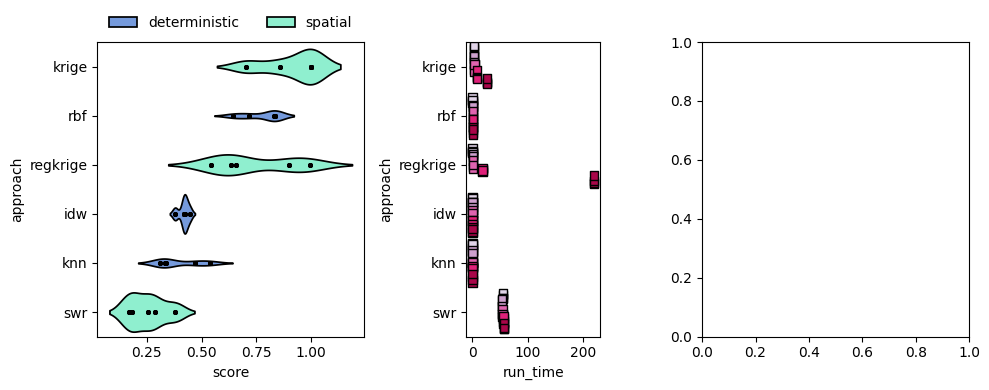

In [252]:
import seaborn as sns
data = big_data
colors = ["cornflowerblue", "aquamarine"]
grf_pal = {"percentage": sns.color_palette('PuRd', n_colors = len(test_percentages)), \
           "maptag": sns.color_palette('Oranges', n_colors = len(test_ranges))}

scatter_aes = {"linewidth":1, "edgecolor":'k', "legend":False}

fig, axs = plt.subplots(1,3,figsize = (10,4), gridspec_kw={'width_ratios':[2,1,2]})
sns.violinplot(data, x='score', y ='approach', hue = 'category', \
               order=data.groupby('approach')['score'].mean().sort_values(ascending=False).index, \
               inner = 'points', palette = sns.color_palette(colors), linecolor = 'k', ax=axs[0])
sns.move_legend(
    axs[0], "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
sns.stripplot(data, x="run_time", y="approach", hue="percentage", dodge = 1 ,jitter = 0.5,\
              order=data.groupby('approach')['score'].mean().sort_values(ascending=False).index, \
              palette = grf_pal['percentage'], marker = 's', size = 6, **scatter_aes, ax = axs[1])

#sns.scatterplot(data, x = "score", y = "rmse_vario", hue = "maptag", size = "percentage", palette = grf_pal['maptag'], **scatter_aes, ax = axs[2])


#plt.show()
fig.tight_layout()
#plt.show()
plt.savefig(projdir + f'/figs/ohbm26/fig1_{template}_{geometry}_{datasource}_samp-{strategy}_summary.svg')

## fig 2

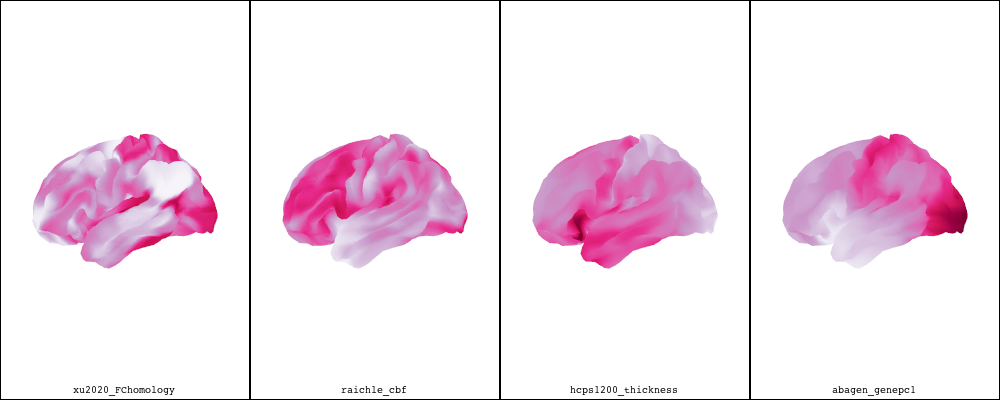

In [291]:
import copy
import pyvista as pv

mesh_aes = {"show_scalar_bar": False,\
            "smooth_shading": False,\
            "specular": 0, "diffuse":0, "ambient":1}


emp_list = ['xu2020_FChomology', 'raichle_cbf', 'hcps1200_thickness', 'abagen_genepc1']
pl0 = pv.Plotter(shape = (1, len(emp_list)),window_size = (1000, 400))

for ti, test_map in enumerate(emp_list):
    pl0.subplot(0,ti)
    tmp = copy.copy(mesh)
    pl0.add_mesh(tmp.rotate_z(180), scalars = test_map, cmap = 'PuRd', **mesh_aes)
    pl0.add_text(test_map, position = 'lower_edge', font_size = 5, font = 'courier')
    pl0.camera_position = 'yz'

#pl0.save_graphic(projdir + '/figs/ohbm26/fig2_empirical_midthickness.svg')
pl0.show(jupyter_backend = 'static')